In [18]:
import pandas as pd



df = pd.DataFrame({
    "hours_studied": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    "marks": [35, 42, 48, 55, 58, 65, 72, 78, 85, 92, 96, 99]
})

df

,hours_studied,marks
0,1,35
1,2,42
2,3,48
3,4,55
4,5,58
5,6,65
6,7,72
7,8,78
8,9,85
9,10,92


In [19]:
mean_marks=df["marks"].mean()
print(mean_marks)
df["prediction_0"] = mean_marks

df


68.75


,hours_studied,marks,prediction_0
0,1,35,68.75
1,2,42,68.75
2,3,48,68.75
3,4,55,68.75
4,5,58,68.75
5,6,65,68.75
6,7,72,68.75
7,8,78,68.75
8,9,85,68.75
9,10,92,68.75


In [20]:
df["residual"]=df["marks"]-df["prediction_0"]
print(df)

    hours_studied  marks  prediction_0  residual
0               1     35         68.75    -33.75
1               2     42         68.75    -26.75
2               3     48         68.75    -20.75
3               4     55         68.75    -13.75
4               5     58         68.75    -10.75
5               6     65         68.75     -3.75
6               7     72         68.75      3.25
7               8     78         68.75      9.25
8               9     85         68.75     16.25
9              10     92         68.75     23.25
10             11     96         68.75     27.25
11             12     99         68.75     30.25


In [24]:
from sklearn.tree import DecisionTreeRegressor
X=df[["hours_studied"]]
Y_residual=df["residual"]
tree_1=DecisionTreeRegressor(
    max_depth=2,
    random_state=42,

)
tree_1.fit(X,Y_residual)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

In [28]:
df["correction_1"]=tree_1.predict(X)
df

,hours_studied,marks,prediction_0,residual,correction_1
0,1,35,68.75,-33.75,-27.083333
1,2,42,68.75,-26.75,-27.083333
2,3,48,68.75,-20.75,-27.083333
3,4,55,68.75,-13.75,-9.416667
4,5,58,68.75,-10.75,-9.416667
5,6,65,68.75,-3.75,-9.416667
6,7,72,68.75,3.25,9.583333
7,8,78,68.75,9.25,9.583333
8,9,85,68.75,16.25,9.583333
9,10,92,68.75,23.25,26.916667


In [26]:
learning_rate = 0.1

print("Learning rate:", learning_rate)

Learning rate: 0.1


In [31]:
df["prediction_1"]=(

    df["prediction_0"]+learning_rate*df["correction_1"]
)
df

,hours_studied,marks,prediction_0,residual,correction_1,prediction_1
0,1,35,68.75,-33.75,-27.083333,66.041667
1,2,42,68.75,-26.75,-27.083333,66.041667
2,3,48,68.75,-20.75,-27.083333,66.041667
3,4,55,68.75,-13.75,-9.416667,67.808333
4,5,58,68.75,-10.75,-9.416667,67.808333
5,6,65,68.75,-3.75,-9.416667,67.808333
6,7,72,68.75,3.25,9.583333,69.708333
7,8,78,68.75,9.25,9.583333,69.708333
8,9,85,68.75,16.25,9.583333,69.708333
9,10,92,68.75,23.25,26.916667,71.441667


In [32]:
df["residual1"]=(df["marks"]-df["prediction_1"])
df

,hours_studied,marks,prediction_0,residual,correction_1,prediction_1,residual1
0,1,35,68.75,-33.75,-27.083333,66.041667,-31.041667
1,2,42,68.75,-26.75,-27.083333,66.041667,-24.041667
2,3,48,68.75,-20.75,-27.083333,66.041667,-18.041667
3,4,55,68.75,-13.75,-9.416667,67.808333,-12.808333
4,5,58,68.75,-10.75,-9.416667,67.808333,-9.808333
5,6,65,68.75,-3.75,-9.416667,67.808333,-2.808333
6,7,72,68.75,3.25,9.583333,69.708333,2.291667
7,8,78,68.75,9.25,9.583333,69.708333,8.291667
8,9,85,68.75,16.25,9.583333,69.708333,15.291667
9,10,92,68.75,23.25,26.916667,71.441667,20.558333


In [33]:
tree_2=DecisionTreeRegressor(
    max_depth=2,
    random_state=42,

)
tree_2.fit(X,df["residual1"])
df["correction_2"]=tree_2.predict(X)
df

,hours_studied,marks,prediction_0,residual,correction_1,prediction_1,residual1,correction_2
0,1,35,68.75,-33.75,-27.083333,66.041667,-31.041667,-24.375000
1,2,42,68.75,-26.75,-27.083333,66.041667,-24.041667,-24.375000
2,3,48,68.75,-20.75,-27.083333,66.041667,-18.041667,-24.375000
3,4,55,68.75,-13.75,-9.416667,67.808333,-12.808333,-8.475000
4,5,58,68.75,-10.75,-9.416667,67.808333,-9.808333,-8.475000
5,6,65,68.75,-3.75,-9.416667,67.808333,-2.808333,-8.475000
6,7,72,68.75,3.25,9.583333,69.708333,2.291667,5.291667
7,8,78,68.75,9.25,9.583333,69.708333,8.291667,5.291667
8,9,85,68.75,16.25,9.583333,69.708333,15.291667,21.991667
9,10,92,68.75,23.25,26.916667,71.441667,20.558333,21.991667


In [35]:
df["prediction_2"] = (
    df["prediction_1"]
    + learning_rate * df["correction_2"]
)

df

,hours_studied,marks,prediction_0,residual,correction_1,prediction_1,residual1,correction_2,prediction_2
0,1,35,68.75,-33.75,-27.083333,66.041667,-31.041667,-24.375000,63.604167
1,2,42,68.75,-26.75,-27.083333,66.041667,-24.041667,-24.375000,63.604167
2,3,48,68.75,-20.75,-27.083333,66.041667,-18.041667,-24.375000,63.604167
3,4,55,68.75,-13.75,-9.416667,67.808333,-12.808333,-8.475000,66.960833
4,5,58,68.75,-10.75,-9.416667,67.808333,-9.808333,-8.475000,66.960833
5,6,65,68.75,-3.75,-9.416667,67.808333,-2.808333,-8.475000,66.960833
6,7,72,68.75,3.25,9.583333,69.708333,2.291667,5.291667,70.237500
7,8,78,68.75,9.25,9.583333,69.708333,8.291667,5.291667,70.237500
8,9,85,68.75,16.25,9.583333,69.708333,15.291667,21.991667,71.907500
9,10,92,68.75,23.25,26.916667,71.441667,20.558333,21.991667,73.640833


In [36]:
df["residual_2"] = (
    df["marks"] - df["prediction_2"]
)

print(df)

    hours_studied  marks  prediction_0  residual  correction_1  prediction_1  \
0               1     35         68.75    -33.75    -27.083333     66.041667   
1               2     42         68.75    -26.75    -27.083333     66.041667   
2               3     48         68.75    -20.75    -27.083333     66.041667   
3               4     55         68.75    -13.75     -9.416667     67.808333   
4               5     58         68.75    -10.75     -9.416667     67.808333   
5               6     65         68.75     -3.75     -9.416667     67.808333   
6               7     72         68.75      3.25      9.583333     69.708333   
7               8     78         68.75      9.25      9.583333     69.708333   
8               9     85         68.75     16.25      9.583333     69.708333   
9              10     92         68.75     23.25     26.916667     71.441667   
10             11     96         68.75     27.25     26.916667     71.441667   
11             12     99         68.75  

In [37]:
print(
    df[
        [
            "hours_studied",
            "marks",
            "prediction_0",
            "prediction_1",
            "prediction_2"
        ]
    ]
)

    hours_studied  marks  prediction_0  prediction_1  prediction_2
0               1     35         68.75     66.041667     63.604167
1               2     42         68.75     66.041667     63.604167
2               3     48         68.75     66.041667     63.604167
3               4     55         68.75     67.808333     66.960833
4               5     58         68.75     67.808333     66.960833
5               6     65         68.75     67.808333     66.960833
6               7     72         68.75     69.708333     70.237500
7               8     78         68.75     69.708333     70.237500
8               9     85         68.75     69.708333     71.907500
9              10     92         68.75     71.441667     73.640833
10             11     96         68.75     71.441667     73.640833
11             12     99         68.75     71.441667     73.640833


In [38]:
from sklearn.metrics import mean_squared_error

mse_0 = mean_squared_error(
    df["marks"],
    df["prediction_0"]
)

mse_1 = mean_squared_error(
    df["marks"],
    df["prediction_1"]
)

mse_2 = mean_squared_error(
    df["marks"],
    df["prediction_2"]
)

print("Initial MSE:", mse_0)
print("After Tree 1:", mse_1)
print("After Tree 2:", mse_2)

Initial MSE: 430.1875
After Tree 1: 352.35743055555577
After Tree 2: 289.20719652777785


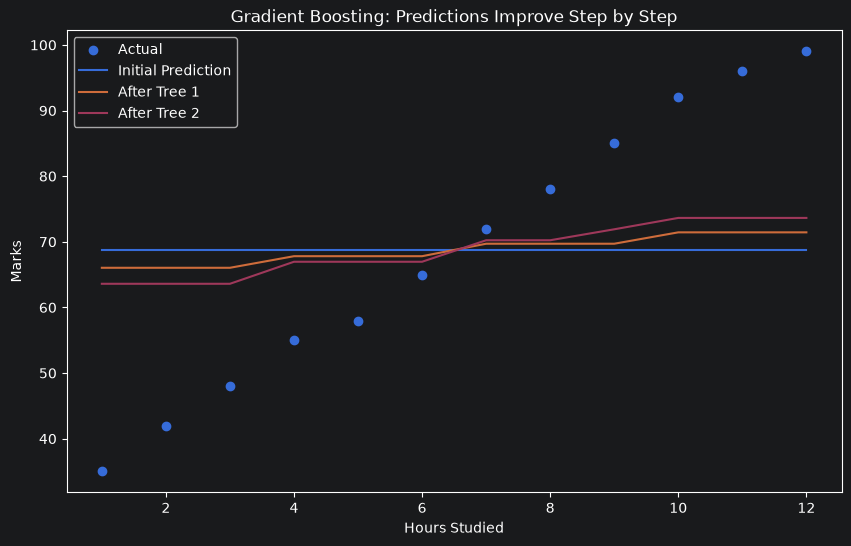

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df["hours_studied"],
    df["marks"],
    label="Actual"
)

plt.plot(
    df["hours_studied"],
    df["prediction_0"],
    label="Initial Prediction"
)

plt.plot(
    df["hours_studied"],
    df["prediction_1"],
    label="After Tree 1"
)

plt.plot(
    df["hours_studied"],
    df["prediction_2"],
    label="After Tree 2"
)

plt.xlabel("Hours Studied")
plt.ylabel("Marks")

plt.title("Gradient Boosting: Predictions Improve Step by Step")

plt.legend()

plt.show()

In [41]:
print(
    df[
        [
            "hours_studied",
            "marks",
            "prediction_0",
            "prediction_1",
            "prediction_2"
        ]
    ]
)

    hours_studied  marks  prediction_0  prediction_1  prediction_2
0               1     35         68.75     66.041667     63.604167
1               2     42         68.75     66.041667     63.604167
2               3     48         68.75     66.041667     63.604167
3               4     55         68.75     67.808333     66.960833
4               5     58         68.75     67.808333     66.960833
5               6     65         68.75     67.808333     66.960833
6               7     72         68.75     69.708333     70.237500
7               8     78         68.75     69.708333     70.237500
8               9     85         68.75     69.708333     71.907500
9              10     92         68.75     71.441667     73.640833
10             11     96         68.75     71.441667     73.640833
11             12     99         68.75     71.441667     73.640833


Tree  1 | MSE = 352.3574
Tree  2 | MSE = 289.2072
Tree  3 | MSE = 237.6432
Tree  4 | MSE = 194.8348
Tree  5 | MSE = 160.3516
Tree  6 | MSE = 131.7692
Tree  7 | MSE = 108.7554
Tree  8 | MSE = 89.6692
Tree  9 | MSE = 73.7137
Tree 10 | MSE = 60.7220

FINAL PREDICTIONS
    hours_studied  marks  prediction_0  prediction_10  residual_10
0               1     35         68.75      49.183019   -14.183019
1               2     42         68.75      51.069417    -9.069417
2               3     48         68.75      54.688256    -6.688256
3               4     55         68.75      60.390200    -5.390200
4               5     58         68.75      61.416150    -3.416150
5               6     65         68.75      65.756365    -0.756365
6               7     72         68.75      71.748374     0.251626
7               8     78         68.75      73.964042     4.035958
8               9     85         68.75      79.361242     5.638758
9              10     92         68.75      85.300460     6.6995

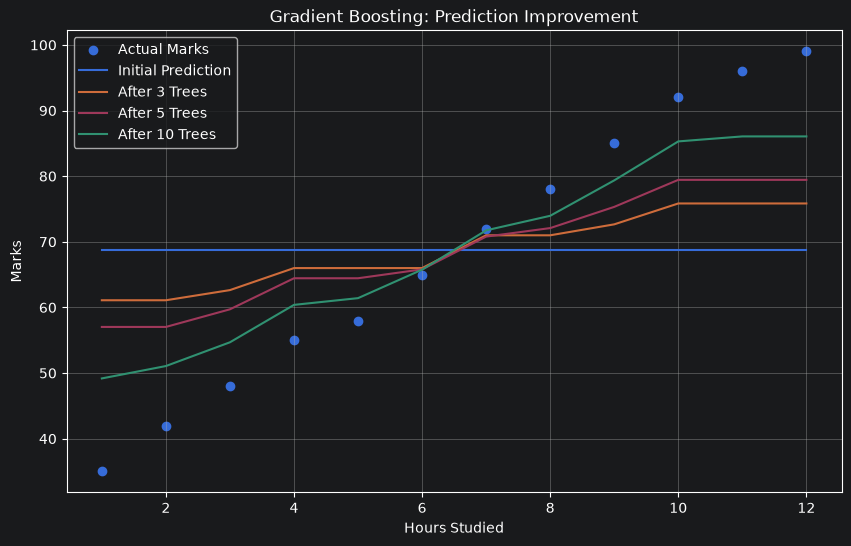

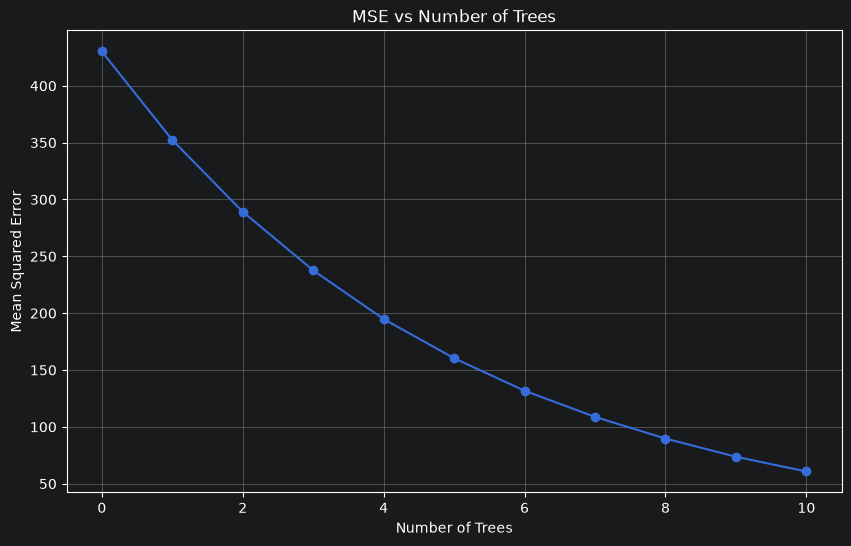

In [45]:
# ==========================================
# GRADIENT BOOSTING - TREE 0 TO TREE 10
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error


# ==========================================
# 1. CREATE DATASET
# ==========================================

df = pd.DataFrame({
    "hours_studied": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    "marks": [35, 42, 48, 55, 58, 65, 72, 78, 85, 92, 96, 99]
})

X = df[["hours_studied"]]
y = df["marks"]


# ==========================================
# 2. PARAMETERS
# ==========================================

learning_rate = 0.1
max_depth = 2
n_trees = 10


# ==========================================
# 3. INITIAL PREDICTION
# ==========================================

prediction = y.mean()

df["prediction_0"] = prediction


# ==========================================
# 4. INITIAL ERROR
# ==========================================

residual = y - prediction

df["residual_0"] = residual


# ==========================================
# 5. STORE RESULTS
# ==========================================

predictions = {
    0: df["prediction_0"].copy()
}

mse_scores = {
    0: mean_squared_error(y, df["prediction_0"])
}


# ==========================================
# 6. BUILD TREE 1 TO TREE 10
# ==========================================

for tree_number in range(1, n_trees + 1):

    # Create a new Decision Tree
    tree = DecisionTreeRegressor(
        max_depth=max_depth,
        random_state=42
    )

    # Train tree on current errors
    tree.fit(X, residual)

    # Tree predicts a correction
    correction = tree.predict(X)

    # Update the overall prediction
    prediction = (
        prediction
        + learning_rate * correction
    )

    # Calculate remaining error
    residual = y - prediction

    # Store prediction
    predictions[tree_number] = prediction.copy()

    # Calculate MSE
    mse = mean_squared_error(
        y,
        prediction
    )

    mse_scores[tree_number] = mse

    print(
        f"Tree {tree_number:2d} | "
        f"MSE = {mse:.4f}"
    )


# ==========================================
# 7. ADD FINAL PREDICTION TO DATAFRAME
# ==========================================

df["prediction_10"] = predictions[10]

df["residual_10"] = (
    y - df["prediction_10"]
)


# ==========================================
# 8. SHOW FINAL RESULTS
# ==========================================

print("\n================================")
print("FINAL PREDICTIONS")
print("================================")

print(
    df[
        [
            "hours_studied",
            "marks",
            "prediction_0",
            "prediction_10",
            "residual_10"
        ]
    ]
)


# ==========================================
# 9. SHOW MSE IMPROVEMENT
# ==========================================

print("\n================================")
print("MSE AFTER EACH TREE")
print("================================")

for tree_number, mse in mse_scores.items():

    print(
        f"Tree {tree_number:2d}: "
        f"{mse:.4f}"
    )


# ==========================================
# 10. VISUALIZE IMPROVEMENT
# ==========================================

plt.figure(figsize=(10, 6))

plt.scatter(
    X["hours_studied"],
    y,
    label="Actual Marks"
)

plt.plot(
    X["hours_studied"],
    predictions[0],
    label="Initial Prediction"
)

plt.plot(
    X["hours_studied"],
    predictions[3],
    label="After 3 Trees"
)

plt.plot(
    X["hours_studied"],
    predictions[5],
    label="After 5 Trees"
)

plt.plot(
    X["hours_studied"],
    predictions[10],
    label="After 10 Trees"
)

plt.xlabel("Hours Studied")
plt.ylabel("Marks")

plt.title(
    "Gradient Boosting: Prediction Improvement"
)

plt.legend()
plt.grid()

plt.show()


# ==========================================
# 11. PLOT MSE
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    list(mse_scores.keys()),
    list(mse_scores.values()),
    marker="o"
)

plt.xlabel("Number of Trees")
plt.ylabel("Mean Squared Error")

plt.title(
    "MSE vs Number of Trees"
)

plt.grid()

plt.show()

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [46]:
df = pd.DataFrame({
    "hours_studied": [
        1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
        11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
        21, 22, 23, 24, 25, 26, 27, 28, 29, 30
    ],

    "marks": [
        35, 39, 43, 47, 51, 55, 59, 62, 66, 69,
        72, 75, 78, 81, 83, 85, 87, 89, 91, 92,
        93, 94, 95, 96, 97, 97, 98, 98, 99, 99
    ]
})

print(df)

    hours_studied  marks
0               1     35
1               2     39
2               3     43
3               4     47
4               5     51
5               6     55
6               7     59
7               8     62
8               9     66
9              10     69
10             11     72
11             12     75
12             13     78
13             14     81
14             15     83
15             16     85
16             17     87
17             18     89
18             19     91
19             20     92
20             21     93
21             22     94
22             23     95
23             24     96
24             25     97
25             26     97
26             27     98
27             28     98
28             29     99
29             30     99


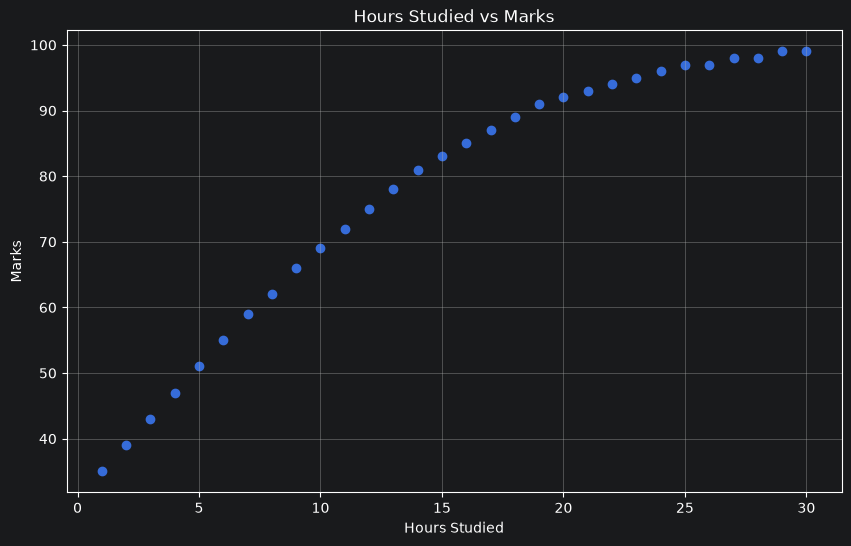

In [47]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["hours_studied"],
    df["marks"]
)

plt.xlabel("Hours Studied")
plt.ylabel("Marks")

plt.title("Hours Studied vs Marks")

plt.grid()

plt.show()

In [48]:
X = df[["hours_studied"]]

y = df["marks"]

In [49]:
print("X:")
print(X.head())

print("\ny:")
print(y.head())


X:
   hours_studied
0              1
1              2
2              3
3              4
4              5

y:
0    35
1    39
2    43
3    47
4    51
Name: marks, dtype: int64


In [51]:
from sklearn.model_selection import  train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [52]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 24
Testing samples: 6


In [55]:

model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=2,
    random_state=42
)

In [56]:
model.fit(
    X_train,
    y_train
)


,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [57]:
y_pred = model.predict(X_test)

print(y_pred)

[97.99768795 83.00758787 94.99889914 86.9997727  62.00023515 72.00045961]


In [58]:
results = pd.DataFrame({
    "Hours Studied": X_test["hours_studied"].values,
    "Actual Marks": y_test.values,
    "Predicted Marks": y_pred
})

results = results.sort_values("Hours Studied")

print(results)

   Hours Studied  Actual Marks  Predicted Marks
4              9            66        62.000235
5             10            69        72.000460
1             16            85        83.007588
3             18            89        86.999773
2             24            96        94.998899
0             28            98        97.997688


In [59]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)

MAE: 1.9993794694645277


In [60]:
mse = mean_squared_error(
    y_test,
    y_pred
)

print("MSE:", mse)

MSE: 5.662283406423657


In [ ]:
r2 = r2_score(
    y_test,
    y_pred
)

print("R² Score:", r2)

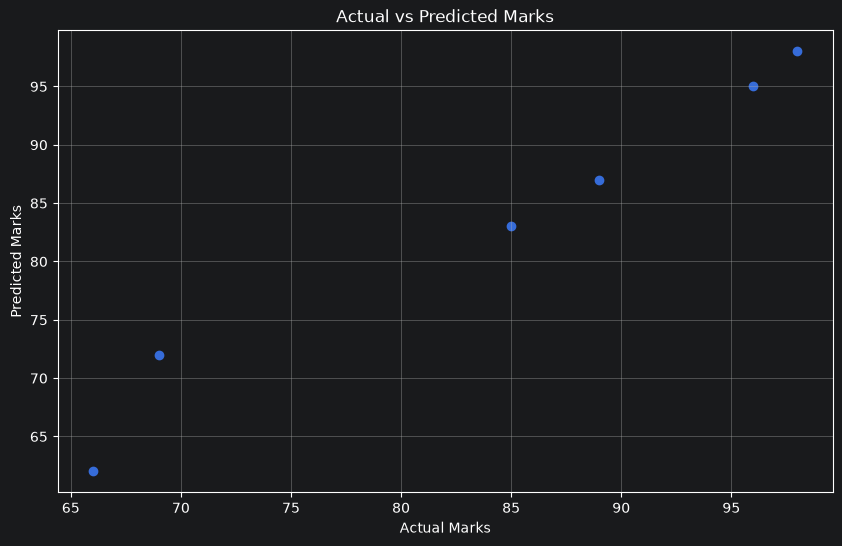

In [61]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")

plt.title("Actual vs Predicted Marks")

plt.grid()

plt.show()

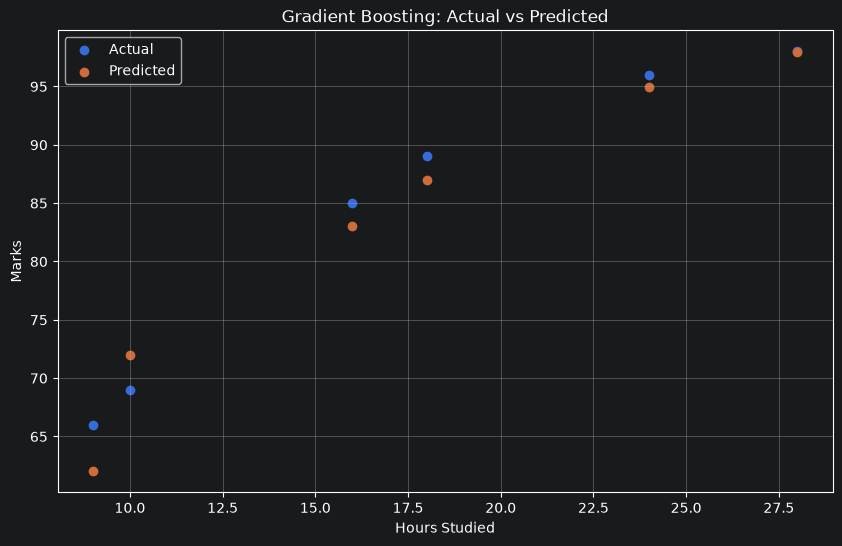

In [62]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_test["hours_studied"],
    y_test,
    label="Actual"
)

plt.scatter(
    X_test["hours_studied"],
    y_pred,
    label="Predicted"
)

plt.xlabel("Hours Studied")
plt.ylabel("Marks")

plt.title(
    "Gradient Boosting: Actual vs Predicted"
)

plt.legend()

plt.grid()

plt.show()

In [64]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

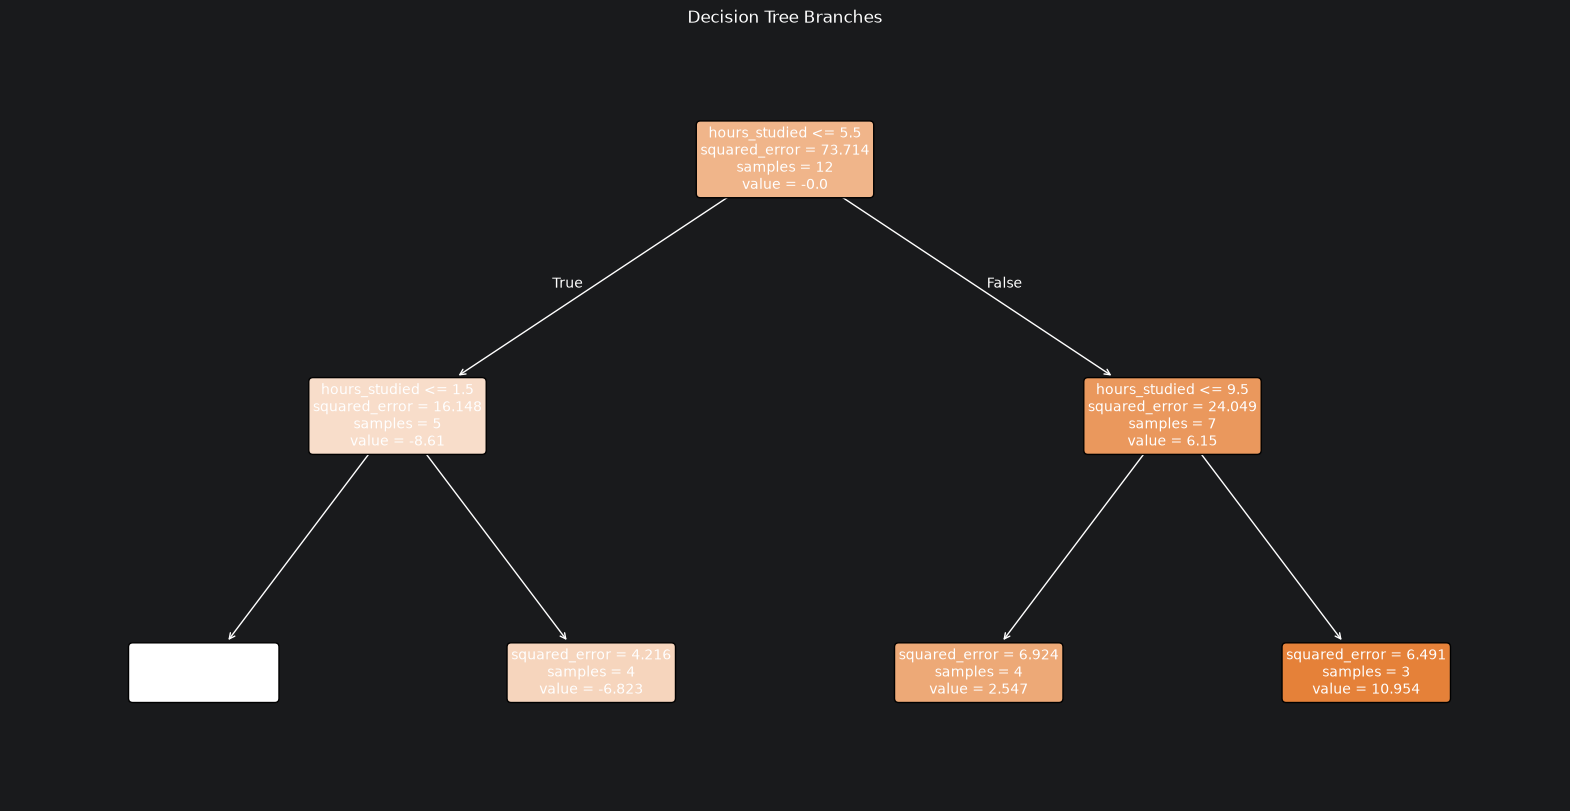

In [65]:
# Visualize
plt.figure(figsize=(20, 10))

plot_tree(
    tree,
    feature_names=["hours_studied"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Branches")

plt.show()